# **Maestría en Inteligencia Artificial Aplicada**

## **Curso: Inteligencia Artificial y Aprendizaje Automático**

### Tecnológico de Monterrey

### Prof Luis Eduardo Falcón Morales

## **Actividad de las Semanas 5 y 6**
### **Problema de asignación de créditos: South German Dataset.**


## **Nombres y matrículas:**



*   José Eduardo De Moraes López A01634782

*   Ana Lucia De Haro Castillo A01796644

*   Nombre y matrícula



## **Ejercicio 1**

In [32]:
# Aquí deberás incluir todas las librerías que requieras durante esta actividad:

import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
import sklearn
import xgboost
import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.metrics import geometric_mean_score
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.metrics import make_scorer
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import KMeansSMOTE
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score, roc_auc_score
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
from sklearn.metrics import average_precision_score
!pip uninstall -y scikit-learn
!pip install --no-cache-dir scikit-learn==1.5

Found existing installation: scikit-learn 1.5.0
Uninstalling scikit-learn-1.5.0:
  Successfully uninstalled scikit-learn-1.5.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 191.6 MB/s eta 0:00:00


In [2]:
# Verificando versiones de algunas de las principales librerías.
# Si algunas no se utilizan, puedes comentarlas.
tmp = !python -V
print(tmp[0])
print('Numpy', np.__version__)
print('Pandas', pd.__version__)
print('Matplotlib', matplotlib.__version__)
print('Seaborn', sns.__version__)
print('Scikit-Learn', sklearn.__version__)
print('XGBoost', xgboost.__version__)

# puedes incluir algunas otras ...


Python 3.11.11
Numpy 1.26.4
Pandas 2.2.2
Matplotlib 3.10.0
Seaborn 0.13.2
Scikit-Learn 1.6.1
XGBoost 2.1.4


In [ ]:
# Si deseas desplegar los Warnings:
#import warnings
#warnings.filterwarnings('ignore')

In [3]:
# Carga los datos del archivo SouthGermanCredit.asc:

# ************* Inlcuye aquí tu código:*****************************




# Lista archivos en la carpeta actual
print(os.listdir("/content/"))

# Verifica si el archivo existe antes de cargarlo
file_path = "/content/SouthGermanCredit.asc"
df = pd.read_csv(file_path, delim_whitespace=True)
print('Dimensión del DataFrame (registros, variables):', df.shape)
display(df.head(3).T)


# *********** Aquí termina la sección de agregar código *************


print('Dimensión del DataFrame (registros,variables):', df.shape)
df.head(3).T

['.config', 'SouthGermanCredit.asc', 'sample_data']
Dimensión del DataFrame (registros, variables): (1000, 21)


<ipython-input-3-4e66dbb5681c>:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True)


,0,1,2
laufkont,1,1,2
laufzeit,18,9,12
moral,4,4,2
verw,2,0,9
hoehe,1049,2799,841
sparkont,1,1,2
beszeit,2,3,4
rate,4,2,2
famges,2,3,2
buerge,1,1,1


Dimensión del DataFrame (registros,variables): (1000, 21)


,0,1,2
laufkont,1,1,2
laufzeit,18,9,12
moral,4,4,2
verw,2,0,9
hoehe,1049,2799,841
sparkont,1,1,2
beszeit,2,3,4
rate,4,2,2
famges,2,3,2
buerge,1,1,1


In [4]:
# Renombra las columnas del alemán al inglés y desplegamos de
# nuevo el DataFrame para ver el resultado obtenido:

# ************* Inlcuye aquí tu código:*****************************

column_translation = {
    "laufkont": "status",
    "laufzeit": "duration",
    "moral": "credit_history",
    "verw": "purpose",
    "hoehe": "amount",
    "sparkont": "savings",
    "beszeit": "employment_duration",
    "rate": "installment_rate",
    "famges": "personal_status_sex",
    "buerge": "other_debtors",
    "wohnzeit": "present_residence",
    "verm": "property",
    "alter": "age",
    "weitkred": "other_installment_plans",
    "wohn": "housing",
    "bishkred": "number_credits",
    "beruf": "job",
    "pers": "people_liable",
    "telef": "telephone",
    "gastarb": "foreign_worker",
    "kredit": "credit_risk"
}

# Renombrar columnas
df.rename(columns=column_translation, inplace=True)


# *********** Aquí termina la sección de agregar código *************


df.head(3).T

,0,1,2
status,1,1,2
duration,18,9,12
credit_history,4,4,2
purpose,2,0,9
amount,1049,2799,841
savings,1,1,2
employment_duration,2,3,4
installment_rate,4,2,2
personal_status_sex,2,3,2
other_debtors,1,1,1


## **Ejercicio 2**

In [5]:
# De la documentación de los datos SouthGermandata se sabe que la clase mayoritaria
# de los buenos clientes se etiquetó con el valor de 1 en la variable de salida
# llamada "credit_risk".
# Veamos:

print(df['credit_risk'].value_counts())

credit_risk
1    700
0    300
Name: count, dtype: int64


In [6]:
# Por lo tanto, realiza a continuación una transformación para que la clase mayoritaria
# sea la clase negativa (es decir, de valor 0) y que la clase minoritaria sea la
# clase positiva (es decir, de valor 1).

# ************* Inlcuye aquí tu código:*****************************


df['credit_risk'] = df['credit_risk'].map({1: 0, 0: 1})


# *********** Aquí termina la sección de agregar código *************


print(df['credit_risk'].value_counts())

credit_risk
0    700
1    300
Name: count, dtype: int64


## **Ejercicio 3**

In [7]:
# Ejercicio 3a.
# Realiza una partición con el porcentaje solicitado para entrenamiento y prueba.
# Los nombres de los conjuntos deberán ser como se indican en los print de abajo:

# ************* Inlcuye aquí tu código:*****************************


X = df.drop(columns=['credit_risk'])  # Todas las columnas excepto la de salida
y = df[['credit_risk']]               # Solo la variable de salida

# Realizar la partición con el porcentaje indicado en el artículo
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.3, stratify=y, random_state=1)


# *********** Aquí termina la sección de agregar código *************


# Mostremos las dimensiones de la partición generada:
print("Dimensiones:")
print("Entrenamiento:", Xtrain.shape, ytrain.shape)
print("Prueba:", Xtest.shape, ytest.shape)

# Y el porcentaje de cada clase de la variable de salida:
tmp = (ytrain.sum()/ytrain.shape[0]).iloc[0]
print("\nPorcentaje clases Negativa (buenos clientes-0):%.2f%%, y Positiva (malos clientes-1):%.2f%%" % (100*(1-tmp),tmp*100))


Dimensiones:
Entrenamiento: (700, 20) (700, 1)
Prueba: (300, 20) (300, 1)

Porcentaje clases Negativa (buenos clientes-0):70.00%, y Positiva (malos clientes-1):30.00%


### **Ejercicio 3b**
### **Con base al porcentaje de los niveles de la variable de salida ¿podemos decir que tenemos un problema de datos desbalanceado? ¿Por qué?**



### ++++++++ Inicia la sección de agregar texto: +++++++++++

Sí, el conjunto de datos presenta un problema de desbalance de clases. Esto se debe a que la clase mayoritaria (buenos clientes - 0) representa el 70% de los datos, mientras que la clase minoritaria (malos clientes - 1) representa solo el 30%. Aunque la diferencia no es extrema, sigue siendo un desbalance que puede afectar el desempeño de identificación de casos del modelo, especialmente en algoritmos que tienden a favorecer la clase mayoritaria.

### ++++++++ Termina la sección de agregar texto: +++++++++++



### **Ejercicio 3c**
### **¿Por qué se hizo el cambio de etiquetas 0 y 1 en la variable de salida?**



### ++++++++ Inicia la sección de agregar texto: +++++++++++

El cambio de etiquetas se realizó para que la clase mayoritaria (buenos clientes) tenga el valor de 0 y la clase minoritaria (malos clientes) tenga el valor de 1. Esto es una práctica común en problemas de clasificación cuando se quiere que el modelo se enfoque en la detección de la clase de interés (en este caso, los clientes que representan un riesgo crediticio). Al hacer este cambio, se facilita la interpretación de métricas como la sensibilidad (recall) y se pueden aplicar estrategias para manejar el desbalance, como el uso de técnicas de sobremuestreo o pesos en la función de pérdida.

### ++++++++ Termina la sección de agregar texto: +++++++++++


## **Ejercicio 4**

In [8]:
# De acuerdo a la información de la Tabla 3 del artículo de la IEEE asociado a
# esta Actividad, define a continuación las variables de entrada correspondientes
# de acuerdo a su tipo y como se indica a continuación:

# ************* Inlcuye aquí tu código:*****************************

# Variables numéricas:
lista_paper_num = ['duration', 'amount', 'age']

# Variables ordinales:
lista_paper_ord = ['employment_duration', 'installment_rate', 'present_residence', 'property', 'number_credits', 'job']

# Variables nominales & binarias:
lista_paper_cat = ['status', 'credit_history', 'purpose', 'savings', 'personal_status_sex', 'other_debtors',
                   'other_installment_plans', 'housing', 'people_liable', 'telephone', 'foreign_worker']



# *********** Aquí termina la sección de agregar código *************

print("Para los datos de entrada, veamos la cantidad de cada tipo de variable obtenida:")
print("Variables numéricas:", len(lista_paper_num))
print("Variables ordinales:", len(lista_paper_ord))
print("Variables nominales & binarias:", len(lista_paper_cat))


Para los datos de entrada, veamos la cantidad de cada tipo de variable obtenida:
Variables numéricas: 3
Variables ordinales: 6
Variables nominales & binarias: 11


## **Ejercicio 5**

📊 Estadísticas Descriptivas para Variables Numéricas:
         duration        amount         age
count  700.000000    700.000000  700.000000
mean    20.751429   3199.507143   35.555714
std     12.001833   2763.826833   11.224897
min      4.000000    276.000000   19.000000
25%     12.000000   1335.500000   27.000000
50%     18.000000   2238.000000   33.000000
75%     24.000000   3921.000000   41.000000
max     72.000000  18424.000000   75.000000


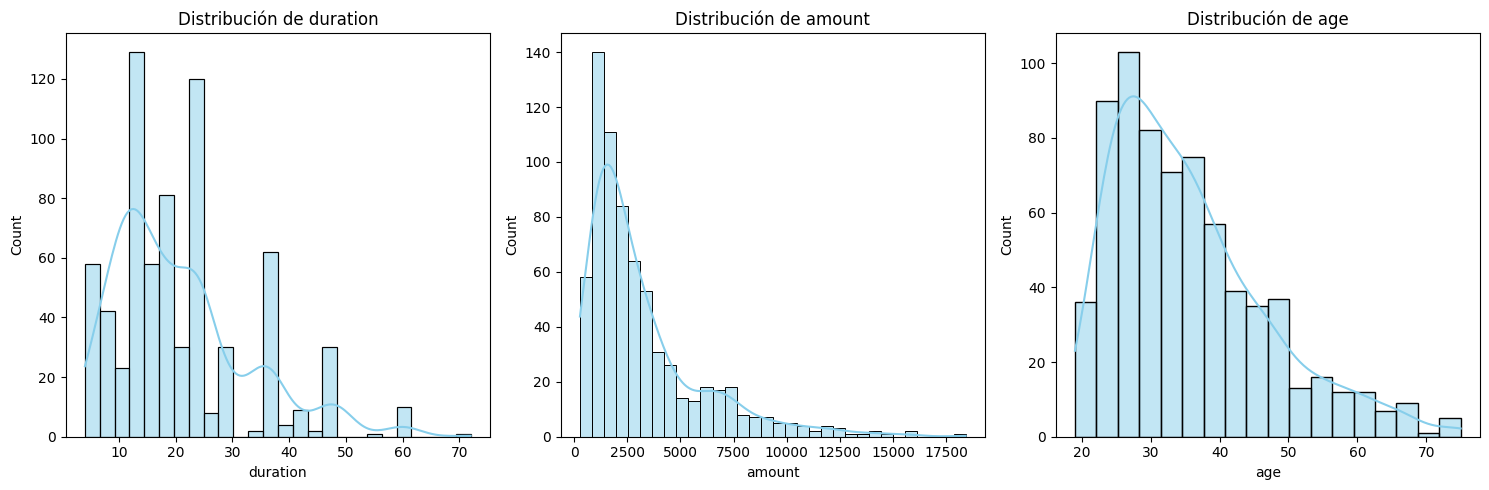

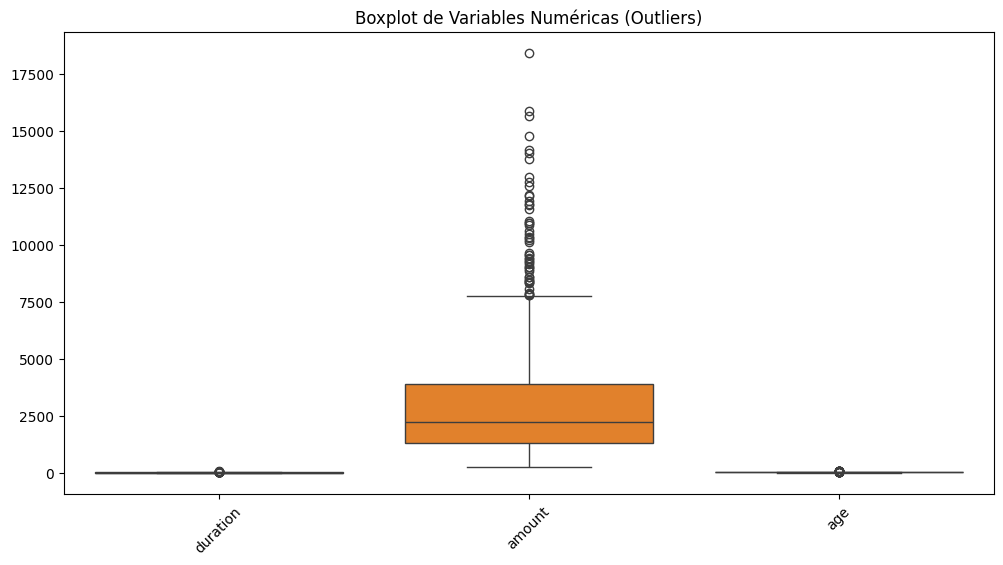

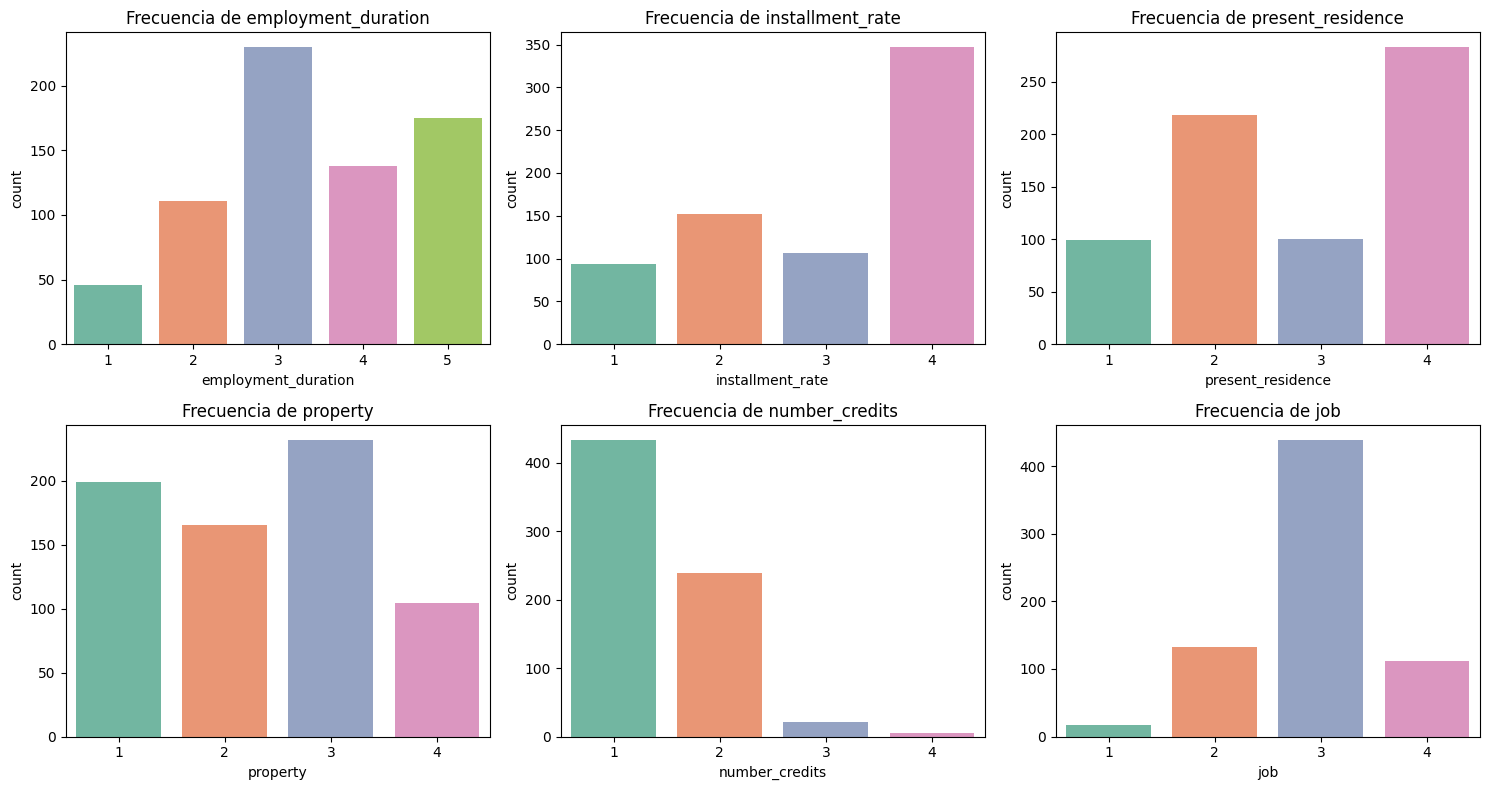

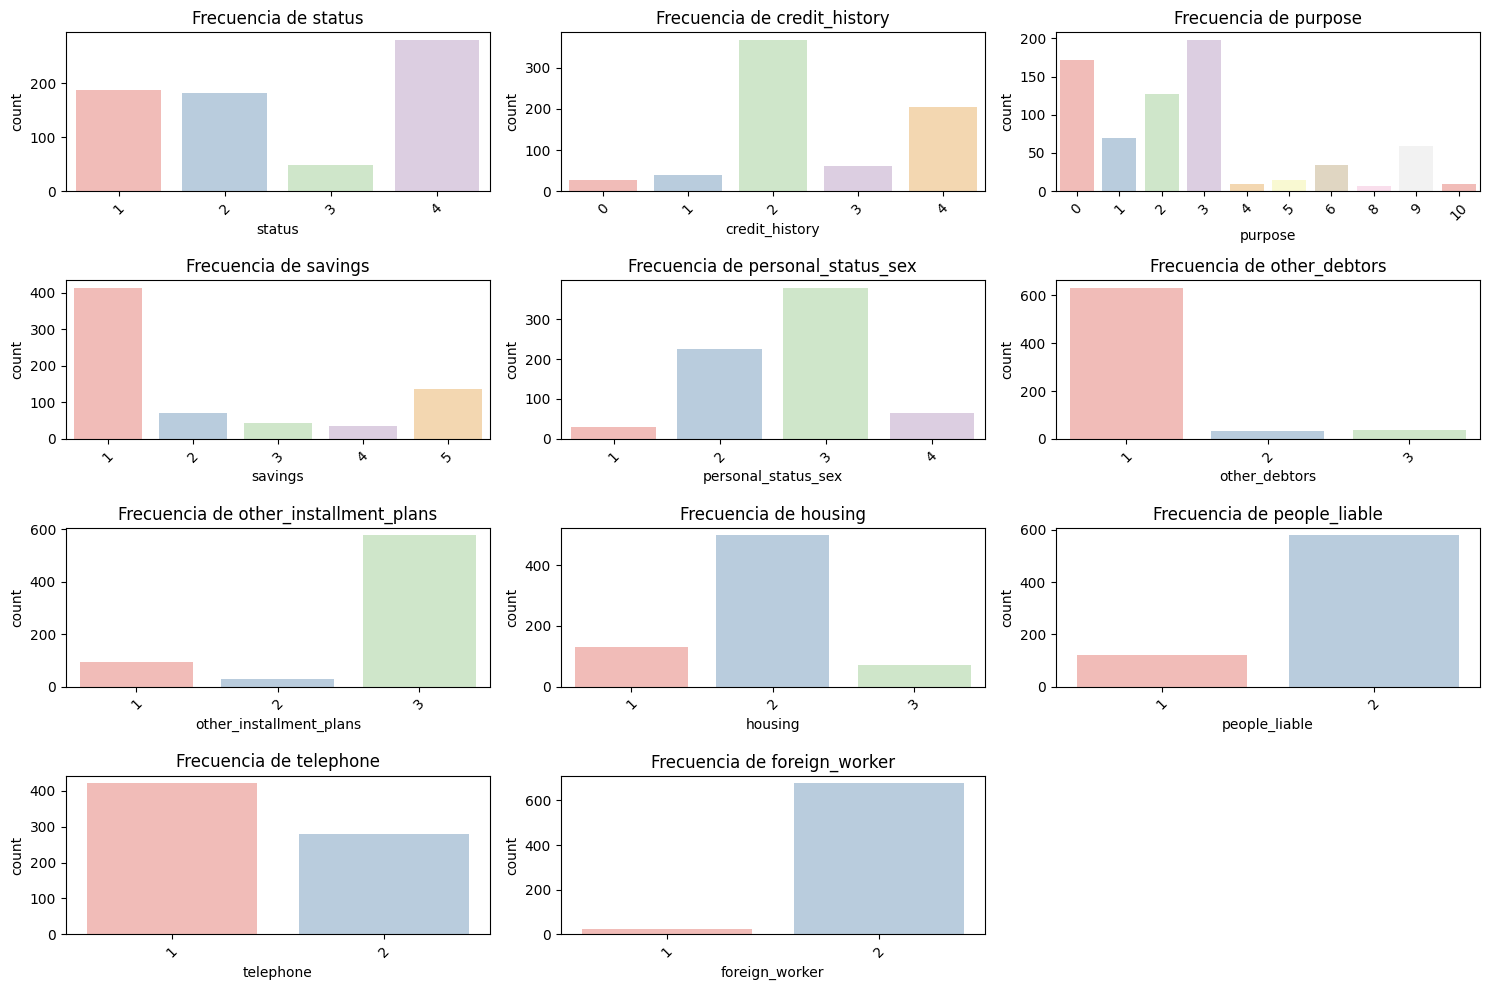

In [9]:
# En esta sección puedes incluir todas las celdas que consideres necesarias para
# visualizar o bien obtener información de cada tipo de variable y te ayude a
# determinar qué transformaciones aplicarás a cada una en el módulo de Pipeline.

# Descripción de variables numéricas
print("📊 Estadísticas Descriptivas para Variables Numéricas:")
print(Xtrain[lista_paper_num].describe())

# ========== Análisis de Variables Numéricas ==========
plt.figure(figsize=(15, 5))
for i, column in enumerate(lista_paper_num, 1):
    plt.subplot(1, 3, i)
    sns.histplot(Xtrain[column], kde=True, color='skyblue')
    plt.title(f'Distribución de {column}')
plt.tight_layout()
plt.show()

# Boxplots para identificar outliers en variables numéricas
plt.figure(figsize=(12, 6))
sns.boxplot(data=Xtrain[lista_paper_num])
plt.title("Boxplot de Variables Numéricas (Outliers)")
plt.xticks(rotation=45)
plt.show()

# ========== Análisis de Variables Ordinales ==========
plt.figure(figsize=(15, 8))
for i, column in enumerate(lista_paper_ord, 1):
    plt.subplot(2, 3, i)
    sns.countplot(x=Xtrain[column], palette='Set2', hue=Xtrain[column], legend=False)
    plt.title(f'Frecuencia de {column}')
plt.tight_layout()
plt.show()

# ========== Análisis de Variables Categóricas y Binarias ==========
plt.figure(figsize=(15, 10))
for i, column in enumerate(lista_paper_cat, 1):
    plt.subplot(4, 3, i)
    sns.countplot(x=Xtrain[column], palette='Pastel1', hue=Xtrain[column], legend=False)
    plt.title(f'Frecuencia de {column}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




In [10]:
# Una vez analizados los datos de entrada, las transformaciones que se aplicarán
# a cada tipo de variable usando la clase Pipeline de sklearn son las siguientes:


# ************* Inlcuye aquí tu código:*****************************
numeric_columns = ['duration', 'amount', 'age']
ordinal_columns = ['employment_duration', 'installment_rate', 'present_residence', 'property', 'number_credits', 'job']
binary_columns = ['people_liable', 'telephone', 'foreign_worker']
nominal_columns = ['status', 'credit_history', 'purpose', 'savings', 'personal_status_sex', 'other_debtors',
                   'other_installment_plans', 'housing']
# Variables numéricas:
numericas_pipeline = Pipeline(steps=[
    ('impMediana', SimpleImputer(strategy='median')),        # Imputación usando la mediana
    ('escalaNum', MinMaxScaler(feature_range=(1, 2)))       # Escalado en rango (1, 2)
])
numericas_pipeline_nombres = numeric_columns




# Variables categóricas-Nominales:
catNom_pipeline = Pipeline(steps=[
    ('impModa', SimpleImputer(strategy='most_frequent')),   # Imputación con la moda
    ('OneHotE', OneHotEncoder(handle_unknown='ignore', drop='first'))  # Codificación One-Hot sin primera categoría
])
catNom_pipeline_nombres = nominal_columns


# Variables categóricas-ordinales:
catOrd_pipeline = Pipeline(steps=[
    ('impModa', SimpleImputer(strategy='most_frequent'))    # Imputación con la moda
])
catOrd_pipeline_nombres = ordinal_columns

# Variables categóricas-binarias:
catBin_pipeline = Pipeline(steps=[
    ('impModa', SimpleImputer(strategy='most_frequent')),   # Imputación con la moda
    ('OneHotE', OneHotEncoder(handle_unknown='ignore', drop='first'))  # Codificación One-Hot, sin primera categoría
])
catBin_pipeline_nombres = binary_columns


# Conjuntas las transformaciones de todo tipo de variable y
# deja sin procesar aquellas que hayas decidido no transformar:

columnasTransformer = ColumnTransformer(transformers=[
    ('numpipe', numericas_pipeline, numericas_pipeline_nombres),
    ('catord', catOrd_pipeline, catOrd_pipeline_nombres),
    ('catnom', catNom_pipeline, catNom_pipeline_nombres),
    ('catbin', catBin_pipeline, catBin_pipeline_nombres)
], remainder='passthrough')




# *********** Aquí termina la sección de agregar código *************



Xtmp = Xtrain.copy()
tmp = columnasTransformer.fit_transform(Xtmp)
print("Dimensión de los datos de entrada:")
print("antes de aplicar las transformaciones:", Xtmp.shape)
print("después de aplicar las transformaciones:", tmp.shape)


Dimensión de los datos de entrada:
antes de aplicar las transformaciones: (700, 20)
después de aplicar las transformaciones: (700, 41)


## **Ejercicio 6**

In [11]:
# Como se va a utilizar Validación-Cruzada, concatena los conjuntos de entrenamiento
# y prueba en uno nuevo conjunto aumentado que llamaremos trainval:


# ************* Inlcuye aquí tu código:**************************


Xtraintest = pd.concat([Xtrain, Xtest], axis=0)  # Concatenamos las variables de entrada (X)
ytraintest = pd.concat([ytrain, ytest], axis=0)  # Concatenamos las variables de salida (y)


# *********** Aquí termina la sección de agregar código *************


# Veamos cuántas variables nuevas se introducen con las transformaciones One-Hot-Encoding:
Xtmp = Xtraintest.copy()
tmp = columnasTransformer.fit_transform(Xtmp)
print("Dimensión de las variables de entrada ANTES de las transformaciones:", Xtmp.shape)
print("Dimensión de las variables de entrada DESPUÉS de las transformaciones:", tmp.shape)

Dimensión de las variables de entrada ANTES de las transformaciones: (1000, 20)
Dimensión de las variables de entrada DESPUÉS de las transformaciones: (1000, 41)


## **Ejercicio 7**

In [12]:
# Definimos una función que evaluará cada modelo con diferentes tipos de métricas,
# así como incluyendo algún método de submuestreo o sobremuestreo.

def mi_fun(modelo, nombre, Xtraintest, ytraintest, metodo_uo=None):
        """
        Se lleva a cabo el proceso de entrenamiento y evaluación
        con diferentes métricas.
        Args:
             modelo: modelo con la configuración deseada
             nombre: nombre del modelo
             Xtriantest, ytraintest: Variables de entrada y variable de salida
             mod_uo: método de submuestreo o sobremuestreo, si aplica.
        """

        pipeline = ImbPipeline(steps=[
            ('preprocesamiento', columnasTransformer),
            ('sub_sobre_muestreo', metodo_uo),
            ('model', modelo)
        ])

        micv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=5)
        mismetricas = {
            'miaccuracy': 'accuracy',
            'miprecision': 'precision',
            'mirecall': 'recall',
            'mifi': 'f1',
            'miauc': 'roc_auc',
            'migmean': make_scorer(geometric_mean_score)
        }

        scores = cross_validate(pipeline, Xtraintest, np.ravel(ytraintest), scoring=mismetricas, cv=micv, return_train_score=True)

        print('>> %s' % nombre)
        for j, k in enumerate(list(scores.keys())):
            if j > 1:
                print('\t %s %.4f (%.3f)' % (k, np.nanmean(scores[k]), np.nanstd(scores[k])))



### **Ejercicio 7a: Regresión Logística**

In [13]:
# Regresión Logística - Logistic Regression-LR:
# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

# Puedes consultar la siguiente liga para los métodos de submuestreo o sobremuestreo:
# https://imbalanced-learn.org/stable/references/over_sampling.html

# ************* Inlcuye aquí tu código:**************************

nombre = "Regresión_Logística"

# Selecciona la configuración de valores de hiperparámetros que consideres
# te da el mejor desempeño:

modelo = LogisticRegression(solver='liblinear',
    C=1.0,
    max_iter=200)


# Selecciona el método de submuestreo o sobremuestreo, si lo deseas incluir.
metodo_uo = KMeansSMOTE(random_state=1, cluster_balance_threshold=0.01)


# *********** Aquí termina la sección de agregar código *************


# Evaluemos la configuración seleccionada:
mi_fun(modelo,nombre, Xtraintest, ytraintest, metodo_uo)



>> Regresión_Logística
	 test_miaccuracy 0.7297 (0.023)
	 train_miaccuracy 0.7581 (0.009)
	 test_miprecision 0.5395 (0.032)
	 train_miprecision 0.5751 (0.012)
	 test_mirecall 0.6978 (0.066)
	 train_mirecall 0.7425 (0.020)
	 test_mifi 0.6069 (0.035)
	 train_mifi 0.6480 (0.012)
	 test_miauc 0.7790 (0.028)
	 train_miauc 0.8264 (0.007)
	 test_migmean 0.7188 (0.030)
	 train_migmean 0.7534 (0.010)


### **Ejercicio 7b: k-Vecinos Más Cercanos (kNN)**

In [14]:
# k-Vecinos más Cercanos : k-Nearest-Neighbors-kNN:
# https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html


# ************* Inlcuye aquí tu código:**************************

nombre = "kNN"
modelo = KNeighborsClassifier(n_neighbors=11, weights='uniform')
metodo_uo = KMeansSMOTE(random_state=1, cluster_balance_threshold=0.01)


# *********** Aquí termina la sección de agregar código *************


# Evaluemos la configuración seleccionada:
mi_fun(modelo, nombre, Xtraintest, ytraintest, metodo_uo)


>> kNN
	 test_miaccuracy 0.5967 (0.039)
	 train_miaccuracy 0.6633 (0.014)
	 test_miprecision 0.4064 (0.033)
	 train_miprecision 0.4669 (0.012)
	 test_mirecall 0.7400 (0.065)
	 train_mirecall 0.8542 (0.028)
	 test_mifi 0.5240 (0.040)
	 train_mifi 0.6035 (0.013)
	 test_miauc 0.6863 (0.043)
	 train_miauc 0.8182 (0.013)
	 test_migmean 0.6281 (0.039)
	 train_migmean 0.7044 (0.013)


### **Ejercicio 7c: Arbol de decisiones**

In [15]:
# Árbol de decisiones-DecisionTree-DT:
# https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html


# ************* Inlcuye aquí tu código:**************************

nombre = "Arbol de decisiones"
modelo = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=1)
metodo_uo = KMeansSMOTE(random_state=1, cluster_balance_threshold=0.01)


# *********** Aquí termina la sección de agregar código *************


# Evaluemos la configuración seleccionada:
mi_fun(modelo, nombre, Xtraintest, ytraintest, metodo_uo)


>> Arbol de decisiones
	 test_miaccuracy 0.6527 (0.038)
	 train_miaccuracy 0.6936 (0.019)
	 test_miprecision 0.4503 (0.038)
	 train_miprecision 0.4953 (0.021)
	 test_mirecall 0.6878 (0.101)
	 train_mirecall 0.7414 (0.068)
	 test_mifi 0.5411 (0.049)
	 train_mifi 0.5914 (0.016)
	 test_miauc 0.6941 (0.045)
	 train_miauc 0.7519 (0.008)
	 test_migmean 0.6581 (0.042)
	 train_migmean 0.7039 (0.014)


### **Ejercicio 7d: Bosque Aleatorio - Random Forest**

In [16]:
# Bosque Aleatorio-RandomForest-RF:
# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html


# ************* Inlcuye aquí tu código:**************************

nombre = "Random Forest"
modelo = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=1)
metodo_uo = KMeansSMOTE(random_state=1, cluster_balance_threshold=0.01)


# *********** Aquí termina la sección de agregar código *************


# Evaluemos la configuración seleccionada:
mi_fun(modelo, nombre, Xtraintest, ytraintest, metodo_uo)


>> Random Forest
	 test_miaccuracy 0.7093 (0.025)
	 train_miaccuracy 0.7427 (0.011)
	 test_miprecision 0.5130 (0.033)
	 train_miprecision 0.5570 (0.016)
	 test_mirecall 0.6356 (0.055)
	 train_mirecall 0.7039 (0.023)
	 test_mifi 0.5671 (0.038)
	 train_mifi 0.6215 (0.010)
	 test_miauc 0.7535 (0.024)
	 train_miauc 0.8159 (0.007)
	 test_migmean 0.6854 (0.031)
	 train_migmean 0.7308 (0.008)


### **Ejercicio 7e: XGBoosting**

In [17]:
# XGBoosting:
# https://xgboost.readthedocs.io/en/latest/python/python_api.html#xgboost.XGBClassifier
# https://xgboost.readthedocs.io/en/stable/parameter.html


# ************* Inlcuye aquí tu código:**************************

nombre = "XGB"
modelo = XGBClassifier(n_estimators=1000, max_depth=3, learning_rate=0.001, random_state=1)
metodo_uo = KMeansSMOTE(random_state=1, cluster_balance_threshold=0.01)


# *********** Aquí termina la sección de agregar código *************


# Evaluemos la configuración seleccionada:
mi_fun(modelo, nombre, Xtraintest, ytraintest, metodo_uo)


>> XGB
	 test_miaccuracy 0.6813 (0.028)
	 train_miaccuracy 0.7163 (0.012)
	 test_miprecision 0.4796 (0.031)
	 train_miprecision 0.5184 (0.014)
	 test_mirecall 0.7211 (0.065)
	 train_mirecall 0.7897 (0.022)
	 test_mifi 0.5753 (0.039)
	 train_mifi 0.6256 (0.010)
	 test_miauc 0.7427 (0.038)
	 train_miauc 0.8065 (0.008)
	 test_migmean 0.6910 (0.033)
	 train_migmean 0.7352 (0.009)


### **Ejercicio 7f: Red Neuronal Multicapa (MLP)**

In [18]:
# Red neuronal de Perceptrón Multicapa-MLP:
# https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html


# ************* Inlcuye aquí tu código:**************************

nombre = "MLP"
modelo = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam', max_iter=2000, alpha=10)
metodo_uo = KMeansSMOTE(random_state=1, cluster_balance_threshold=0.01)


# *********** Aquí termina la sección de agregar código *************


# Evaluemos la configuración seleccionada:
mi_fun(modelo, nombre, Xtraintest, ytraintest, metodo_uo)


>> MLP
	 test_miaccuracy 0.6923 (0.032)
	 train_miaccuracy 0.7105 (0.010)
	 test_miprecision 0.4928 (0.038)
	 train_miprecision 0.5132 (0.013)
	 test_mirecall 0.6856 (0.062)
	 train_mirecall 0.7131 (0.037)
	 test_mifi 0.5719 (0.039)
	 train_mifi 0.5962 (0.011)
	 test_miauc 0.7522 (0.027)
	 train_miauc 0.7838 (0.008)
	 test_migmean 0.6888 (0.033)
	 train_migmean 0.7106 (0.009)


### **Ejercicio 7g: Máquina de Vector Soporte (SVM)**

In [19]:
# Máquina de Vectores de Soporte-SVM:
# https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html


# ************* Inlcuye aquí tu código:**************************

nombre = "SVM"
modelo = SVC(kernel='rbf', C=1, probability=True)
metodo_uo = KMeansSMOTE(random_state=1, cluster_balance_threshold=0.01)


# *********** Aquí termina la sección de agregar código *************


# Evaluemos la configuración seleccionada:
mi_fun(modelo, nombre, Xtraintest, ytraintest, metodo_uo)


>> SVM
	 test_miaccuracy 0.7047 (0.022)
	 train_miaccuracy 0.7418 (0.011)
	 test_miprecision 0.5076 (0.026)
	 train_miprecision 0.5522 (0.015)
	 test_mirecall 0.6744 (0.070)
	 train_mirecall 0.7450 (0.020)
	 test_mifi 0.5771 (0.031)
	 train_mifi 0.6340 (0.009)
	 test_miauc 0.7649 (0.016)
	 train_miauc 0.8314 (0.007)
	 test_migmean 0.6935 (0.026)
	 train_migmean 0.7425 (0.008)


## **Ejercicio 8**


=== Classification Report ===

              precision    recall  f1-score   support

           0       0.70      1.00      0.83       210
           1       1.00      0.01      0.02        90

    accuracy                           0.70       300
   macro avg       0.85      0.51      0.42       300
weighted avg       0.79      0.70      0.58       300


=== Métricas Adicionales ===
Accuracy (%): 70.33
F1-Score (%): 2.20
ROC-AUC (%): 83.06
G-Mean: 0.1054


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  Labels as normalized encodings.


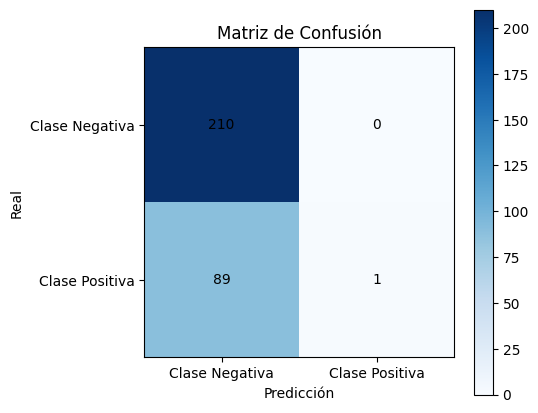

<Figure size 600x600 with 0 Axes>

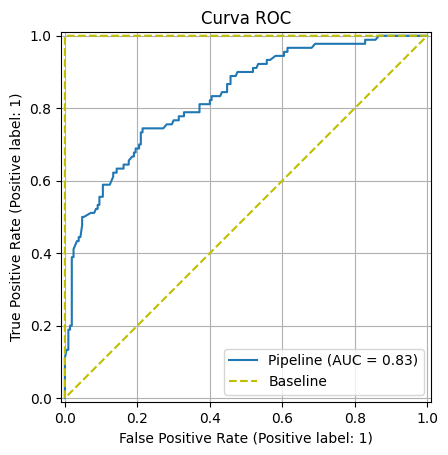

<Figure size 600x600 with 0 Axes>

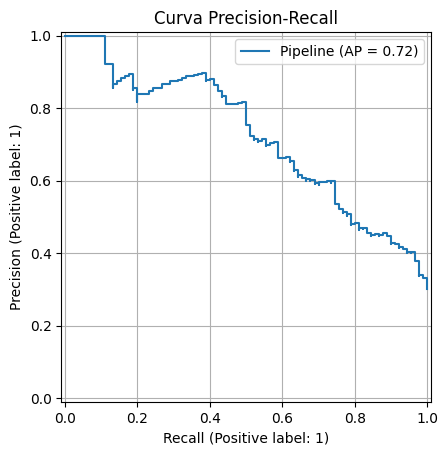


AUC (Área bajo la curva ROC): 83.06%
AP (Área bajo la curva Precision-Recall): 72.13%


In [33]:
# Incluye el reporte del mejor modelo solicitado en el archivo PDF:
#Mejores hiperparametros encontrados:
nombre = "XGB"
modelo = XGBClassifier(n_estimators=1000,
                       max_depth=3,
                       learning_rate=0.001,
                       random_state=1)
metodo_uo = KMeansSMOTE(random_state=1, cluster_balance_threshold=0.01)

mf_pipe = Pipeline(steps=[('ct', columnasTransformer), ('m', modelo)])

# Ajuste del modelo con el conjunto de entrenamiento
mf_pipe.fit(Xtraintest, ytraintest)

# Predicciones con el conjunto de prueba
yhat = mf_pipe.predict(Xtest)
yhat_proba = mf_pipe.predict_proba(Xtest)[:, 1]  # Probabilidades para AUC

# Imprimir el classification report en su formato normal
print("\n=== Classification Report ===\n")
print(classification_report(ytest, yhat))

# Calcular métricas
f1 = f1_score(ytest, yhat)
roc_auc = roc_auc_score(ytest, yhat_proba)
gmean_test = geometric_mean_score(ytest, yhat)

# Imprimir métricas
print("\n=== Métricas Adicionales ===")
print(f"Accuracy (%): {mf_pipe.score(Xtest, ytest) * 100:.2f}")
print(f"F1-Score (%): {f1 * 100:.2f}")
print(f"ROC-AUC (%): {roc_auc * 100:.2f}")
print(f"G-Mean: {gmean_test:.4f}")

# Matriz de confusión
conf_matrix = confusion_matrix(ytest, yhat)
plt.figure(figsize=(5, 5))
plt.imshow(conf_matrix, cmap='Blues', interpolation='nearest')
plt.colorbar()
plt.xticks([0, 1], labels=['Clase Negativa', 'Clase Positiva'])
plt.yticks([0, 1], labels=['Clase Negativa', 'Clase Positiva'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')

# Anotar los valores en la matriz de confusión
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, str(conf_matrix[i, j]), ha='center', va='center', color='black')

plt.show()

# Curva ROC con AUC
plt.figure(figsize=(6, 6))
RocCurveDisplay.from_estimator(mf_pipe, Xtest, ytest)
plt.plot([0, 0, 1, 0], [0, 1, 1, 0], 'y--', label="Baseline")
plt.title('Curva ROC')
plt.legend()
plt.grid()
plt.show()

# Curva Precision-Recall con AUC
plt.figure(figsize=(6, 6))
PrecisionRecallDisplay.from_estimator(mf_pipe, Xtest, ytest)  # Generar curva PR
tasa_positiva = ytest.mean()  # Proporción de positivos en el dataset
plt.legend(loc="upper right")
plt.title('Curva Precision-Recall')
plt.grid()
plt.show()


# AUC y AP
auc = roc_auc_score(ytest, yhat_proba)
print(f'\nAUC (Área bajo la curva ROC): {auc * 100:.2f}%')

ap = average_precision_score(ytest, yhat_proba)
print(f'AP (Área bajo la curva Precision-Recall): {ap * 100:.2f}%')



## **Ejercicio 9**

### **Escribe tus conclusiones finales de la actividad.**

### ++++++++ Inicia la sección de agregar texto: +++++++++++

El análisis de los resultados permitió comprender la complejidad de trabajar con bases de datos desbalanceadas, un desafío frecuente en problemas del mundo real. En este caso, la dificultad radicó en que la clase positiva correspondía a los clientes considerados "malos", quienes representaban solo el 30% del conjunto de datos. Como consecuencia, los modelos tradicionales favorecieron la clase mayoritaria (clientes "buenos"), lo que llevó a predicciones sesgadas y a una baja capacidad de detección de la clase minoritaria. La matriz de confusión evidenció este problema de manera clara: el modelo clasificó correctamente 210 casos como verdaderos negativos, sin generar falsos positivos, lo que implica que todos los clientes "buenos" fueron correctamente identificados. Sin embargo, el desempeño en la clase minoritaria fue extremadamente deficiente, ya que de los 90 clientes considerados "malos", solo uno fue correctamente clasificado como tal (un verdadero positivo), mientras que 89 fueron erróneamente etiquetados como clientes sin riesgo (falsos negativos).

Estos resultados afectaron considerablemente las métricas de evaluación del modelo. La precisión global alcanzó un 70.33%, pero la métrica más crítica en este caso, el recall de la clase minoritaria, fue de apenas 1%, lo que indica que el modelo prácticamente ignoró a los clientes de alto riesgo. En consecuencia, el F1-score de esta clase fue extremadamente bajo (2.20%), reflejando el desbalance en la capacidad de predicción. No obstante, la métrica ROC-AUC alcanzó un 83.06%, lo que sugiere que, si bien el modelo fue incapaz de clasificar correctamente la clase minoritaria en su forma actual, tiene potencial para mejorar con ajustes adecuados.

Para abordar este problema, se implementó KMeans-SMOTE, una estrategia que combina la agrupación de datos con K-Means y el sobremuestreo sintético de SMOTE. Esta técnica permitió generar ejemplos sintéticos más representativos de la clase minoritaria, evitando la sobrecarga de datos artificiales irrelevantes y reduciendo el riesgo de overfitting. Sin embargo, aunque KMeans-SMOTE ayudó a mejorar la calidad de los datos, el modelo aún mostró dificultades para alcanzar un balance adecuado entre precisión y recall. Se evaluaron distintos algoritmos de clasificación, incluyendo Regresión Logística, SVM y XGBoost, siendo este último el que presentó el mejor desempeño en la detección de la clase positiva, aunque a costa de un incremento en los falsos positivos. En este contexto financiero, este aumento de falsos positivos no se considera un problema crítico, ya que solo implicaría una revisión adicional de un cliente que realmente no representa un riesgo, lo cual es un costo aceptable en comparación con la posibilidad de no detectar clientes con alto riesgo financiero.

La actividad permitió cimentar las bases para la aplicación práctica de técnicas de modelado y tratamiento de datos en nuestro ámbito profesional. Se demostró que, aunque los modelos obtenidos aún presentan margen de mejora y están lejos de ser ideales, con ajustes en la selección de características, optimización de hiperparámetros y técnicas adicionales de balanceo, como KMeans-SMOTE, es posible mejorar significativamente su desempeño. Esta experiencia resalta la importancia de evaluar cada modelo no solo desde el punto de vista de métricas estándar como precisión o recall, sino también considerando el impacto real de las decisiones en el contexto específico en el que se aplicarán. KMeans-SMOTE, al mejorar el manejo de las clases desbalanceadas, se presentó como una herramienta crucial en este proceso, permitiendo un avance significativo en la detección de clientes de alto riesgo en un entorno financiero.


### ++++++++ Termina la sección de agregar texto. +++++++++++


>> ### **Fin de la Actividad de las Semanas 5 y 6.**